# 09 — Bayesian Statistics
**References:** Bayes (1763) · Laplace (1812) · Gelman et al. (2013) *BDA3* · McElreath (2020) *Statistical Rethinking*

## Narrative thread
```
Bayesian vs Frequentist -> Prior + Likelihood = Posterior -> Conjugate priors -> Credible intervals -> MCMC preview
```

## Bayesian vs Frequentist

| | **Frequentist** | **Bayesian** |
|---|---|---|
| Parameters | Fixed, unknown constants | Random variables with distributions |
| Probability | Long-run frequency | Degree of belief |
| Data | Random (repeated sampling) | Fixed (what we observed) |
| Inference | Confidence intervals, p-values | Posterior distribution, credible intervals |
| Prior knowledge | Not incorporated | Explicitly modeled |

## Bayes' rule for inference

$$p(\theta \mid \mathbf{x}) = \frac{p(\mathbf{x} \mid \theta)\, p(\theta)}{p(\mathbf{x})} \propto \underbrace{p(\mathbf{x} \mid \theta)}_{\text{likelihood}} \cdot \underbrace{p(\theta)}_{\text{prior}}$$

The **posterior** $p(\theta \mid \mathbf{x})$ summarizes everything we know about $\theta$ after seeing the data.

## Conjugate priors

A prior $p(\theta)$ is **conjugate** to likelihood $p(x \mid \theta)$ if the posterior
belongs to the same family as the prior — making the update analytically tractable.

| Likelihood | Conjugate prior | Posterior |
|---|---|---|
| Bernoulli($p$) | Beta($\alpha, \beta$) | Beta($\alpha + \sum x_i,\; \beta + n - \sum x_i$) |
| Normal($\mu$, $\sigma^2$ known) | Normal($\mu_0, \tau_0^2$) | Normal (precision-weighted average) |
| Poisson($\lambda$) | Gamma($\alpha, \beta$) | Gamma($\alpha + \sum x_i,\; \beta + n$) |

## Credible intervals vs Confidence intervals

A **95% Bayesian credible interval** $[L, U]$ satisfies:
$$P(L \leq \theta \leq U \mid \mathbf{x}) = 0.95$$

This is what most people *think* a confidence interval means — but it is only
valid in the Bayesian framework where $\theta$ is treated as a random variable.

The **Highest Posterior Density (HPD)** interval is the shortest credible interval.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

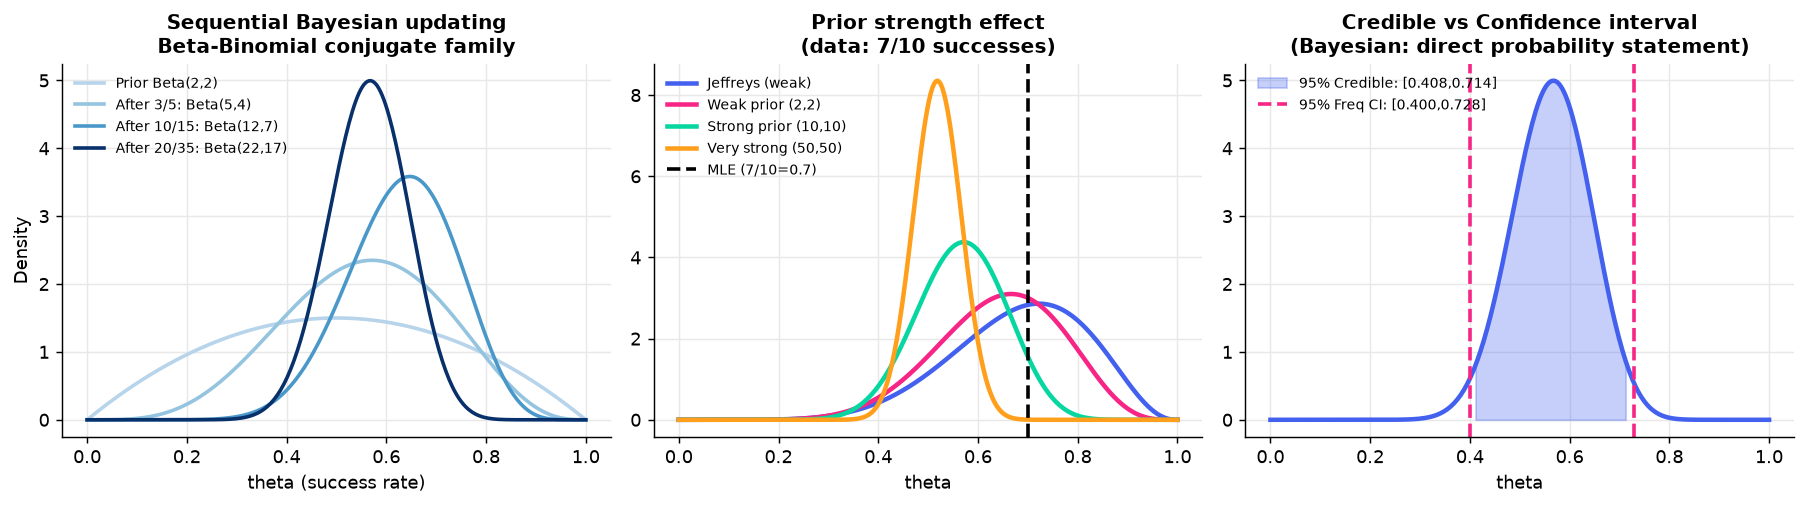

Posterior mean: 0.5641  Posterior mode: 0.5676


In [2]:
from scipy.stats import beta as beta_dist, norm as norm_dist

# ── Beta-Binomial: updating beliefs about a proportion ────────────────────
# Prior: Beta(alpha0, beta0) — our prior belief about the success rate
# Data: x successes in n trials
# Posterior: Beta(alpha0 + x, beta0 + n - x)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Show sequential updating
alpha0, beta0 = 2, 2   # weak prior: centered at 0.5
observations  = [3, 2, 5, 1, 4, 2, 3]  # sequential data

theta_grid = np.linspace(0, 1, 300)
ax = axes[0]
alpha_curr, beta_curr = alpha0, beta0
colors_seq = plt.cm.Blues(np.linspace(0.3, 1.0, len(observations)+1))

ax.plot(theta_grid, beta_dist.pdf(theta_grid, alpha0, beta0),
        color=colors_seq[0], lw=2, label=f'Prior Beta({alpha0},{beta0})')
for i, x_i in enumerate(observations):
    n_i = 5   # 5 trials each batch
    alpha_curr += x_i
    beta_curr  += n_i - x_i
    if i in [0, 2, len(observations)-1]:
        ax.plot(theta_grid, beta_dist.pdf(theta_grid, alpha_curr, beta_curr),
                color=colors_seq[i+1], lw=2,
                label=f'After {sum(observations[:i+1])}/{5*(i+1)}: Beta({alpha_curr},{beta_curr})')

ax.set_xlabel('theta (success rate)'); ax.set_ylabel('Density')
ax.set_title('Sequential Bayesian updating\nBeta-Binomial conjugate family')
ax.legend(fontsize=8)

# ── Effect of prior strength ───────────────────────────────────────────────
x_obs, n_obs = 7, 10   # 7 successes in 10 trials
ax2 = axes[1]
priors = [(0.5, 0.5, 'Jeffreys (weak)'), (2, 2, 'Weak prior (2,2)'),
          (10, 10, 'Strong prior (10,10)'), (50, 50, 'Very strong (50,50)')]
colors_p = ['#4361ee','#f72585','#06d6a0','#ff9f1c']
for (a0, b0, label), c in zip(priors, colors_p):
    a_post = a0 + x_obs; b_post = b0 + n_obs - x_obs
    ax2.plot(theta_grid, beta_dist.pdf(theta_grid, a_post, b_post), color=c, lw=2.5, label=label)
ax2.axvline(x_obs/n_obs, color='black', lw=2, linestyle='--', label='MLE (7/10=0.7)')
ax2.set_xlabel('theta'); ax2.set_title(f'Prior strength effect\n(data: {x_obs}/{n_obs} successes)')
ax2.legend(fontsize=8)

# ── Credible interval vs Confidence interval ──────────────────────────────
alpha_post = alpha0 + sum(observations)
beta_post  = beta0  + len(observations)*5 - sum(observations)
n_total = len(observations)*5
p_hat = alpha_post / (alpha_post + beta_post)

# 95% credible interval
ci_lo, ci_hi = beta_dist.ppf([0.025, 0.975], alpha_post, beta_post)
# 95% confidence interval (frequentist)
freq_ci_lo = p_hat - 1.96 * np.sqrt(p_hat*(1-p_hat)/n_total)
freq_ci_hi = p_hat + 1.96 * np.sqrt(p_hat*(1-p_hat)/n_total)

ax3 = axes[2]
ax3.plot(theta_grid, beta_dist.pdf(theta_grid, alpha_post, beta_post), color='#4361ee', lw=2.5)
ax3.fill_between(theta_grid, beta_dist.pdf(theta_grid, alpha_post, beta_post),
                  where=(theta_grid >= ci_lo) & (theta_grid <= ci_hi),
                  alpha=0.3, color='#4361ee', label=f'95% Credible: [{ci_lo:.3f},{ci_hi:.3f}]')
ax3.axvline(freq_ci_lo, color='#f72585', lw=2, linestyle='--')
ax3.axvline(freq_ci_hi, color='#f72585', lw=2, linestyle='--',
            label=f'95% Freq CI: [{freq_ci_lo:.3f},{freq_ci_hi:.3f}]')
ax3.set_xlabel('theta'); ax3.set_title('Credible vs Confidence interval\n(Bayesian: direct probability statement)')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f'Posterior mean: {p_hat:.4f}  Posterior mode: {(alpha_post-1)/(alpha_post+beta_post-2):.4f}')

## MCMC: sampling from intractable posteriors

When the posterior has no closed form (non-conjugate models), we use
**Markov Chain Monte Carlo (MCMC)** to draw samples from it.

**Metropolis-Hastings algorithm:**
1. Start at $\theta^{(0)}$
2. Propose $\theta^* \sim q(\theta^* \mid \theta^{(t)})$ (e.g., $N(\theta^{(t)}, \sigma^2)$)
3. Compute acceptance ratio: $\rho = \min\left(1,\; \frac{p(\theta^* \mid x)}{p(\theta^{(t)} \mid x)}\right)$
4. Accept with probability $\rho$; else stay at $\theta^{(t)}$
5. Repeat

After a **burn-in** period, the chain converges to the posterior distribution.
Modern practice uses **Hamiltonian Monte Carlo** (Stan, PyMC) which is much more efficient.

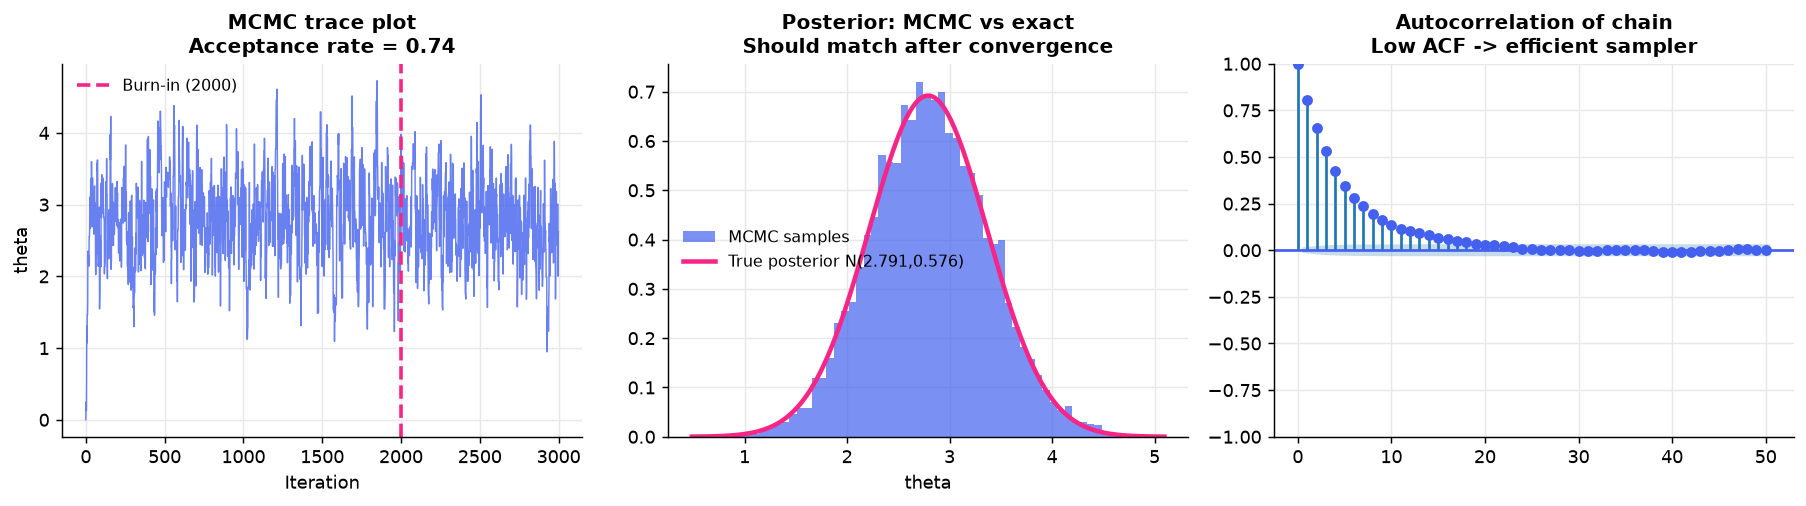

True posterior: N(2.7907, 0.5764^2)
MCMC estimate:  mean=2.8089  std=0.5738
95% credible interval: [1.7073, 3.9448]


In [3]:
# ── Metropolis-Hastings from scratch ──────────────────────────────────────
# Target: Normal posterior (illustrative — we know the truth for validation)
# Likelihood: N(theta, 1); Prior: N(0, 10^2); Data: x = [2.5, 3.1, 2.8]
x_data = np.array([2.5, 3.1, 2.8])
prior_mu, prior_sig = 0, 10
lik_sig = 1

def log_posterior(theta):
    log_lik   = stats.norm.logpdf(x_data, theta, lik_sig).sum()
    log_prior = stats.norm.logpdf(theta, prior_mu, prior_sig)
    return log_lik + log_prior

# True posterior (conjugate Normal)
prior_prec = 1/prior_sig**2
lik_prec   = len(x_data)/lik_sig**2
post_prec  = prior_prec + lik_prec
post_mu    = (prior_prec*prior_mu + lik_prec*x_data.mean()) / post_prec
post_sig   = 1/np.sqrt(post_prec)

# MH sampler
n_iter = 20000
proposal_sd = 0.5
chain = np.zeros(n_iter)
chain[0] = 0.0
accepted = 0
for i in range(1, n_iter):
    proposal = chain[i-1] + np.random.normal(0, proposal_sd)
    log_ratio = log_posterior(proposal) - log_posterior(chain[i-1])
    if np.log(np.random.uniform()) < log_ratio:
        chain[i] = proposal; accepted += 1
    else:
        chain[i] = chain[i-1]

burn_in = 2000
post_samples = chain[burn_in:]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(chain[:3000], color='#4361ee', lw=0.8, alpha=0.8)
axes[0].axvline(burn_in, color='#f72585', lw=2, linestyle='--', label=f'Burn-in ({burn_in})')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('theta')
axes[0].set_title(f'MCMC trace plot\nAcceptance rate = {accepted/n_iter:.2f}')
axes[0].legend(fontsize=9)

theta_range = np.linspace(post_mu - 4*post_sig, post_mu + 4*post_sig, 300)
axes[1].hist(post_samples, bins=60, density=True, color='#4361ee', alpha=0.7, label='MCMC samples')
axes[1].plot(theta_range, norm_dist.pdf(theta_range, post_mu, post_sig),
             color='#f72585', lw=2.5, label=f'True posterior N({post_mu:.3f},{post_sig:.3f})')
axes[1].set_xlabel('theta'); axes[1].set_title('Posterior: MCMC vs exact\nShould match after convergence')
axes[1].legend(fontsize=9)

# ACF of chain
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(post_samples, lags=50, ax=axes[2], color='#4361ee', title='Autocorrelation of chain\nLow ACF -> efficient sampler')

plt.tight_layout()
plt.show()
print(f'True posterior: N({post_mu:.4f}, {post_sig:.4f}^2)')
print(f'MCMC estimate:  mean={post_samples.mean():.4f}  std={post_samples.std():.4f}')
print(f'95% credible interval: [{np.percentile(post_samples,2.5):.4f}, {np.percentile(post_samples,97.5):.4f}]')